In [442]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [443]:
data = pd.read_csv('../data/data4.csv')

train_data, test_data = train_test_split(data, test_size=0.2)

X_train = train_data.drop('y', axis=1)
y_train = train_data['y']

X_test = test_data.drop('y', axis=1)
y_test = test_data['y']

dla zmiennych losowych X, Y
$$
corr(X, Y) = \frac{Cov(X, Y)}{\sqrt{Var(X)Var(Y)}} = E\left[\frac{(X - \mu_{X})}{\sigma_{X}}\frac{(Y - \mu_{Y})}{{\sigma_{Y}}}\right]
$$
dla próbki danych liczy się to odpowiednio esytmując średnią i wariancję.

wartość +1/-1 korelacji odpowiada dodatniej/ujemnej liniowej zależności (tego szukamy regresją liniową)
wynika to z tego, że w nierównosci Holdera równośc zachodzi wtw gdy zmienne są liniowo zależne
$$
    1 = corr(X, Y) \leq \frac{\sqrt{E\left[(X - \mu_{X})^2\right]} \sqrt{E\left[(Y - \mu_{Y})^2\right]}}{\sigma_{X}\sigma_{Y}} = 1
$$

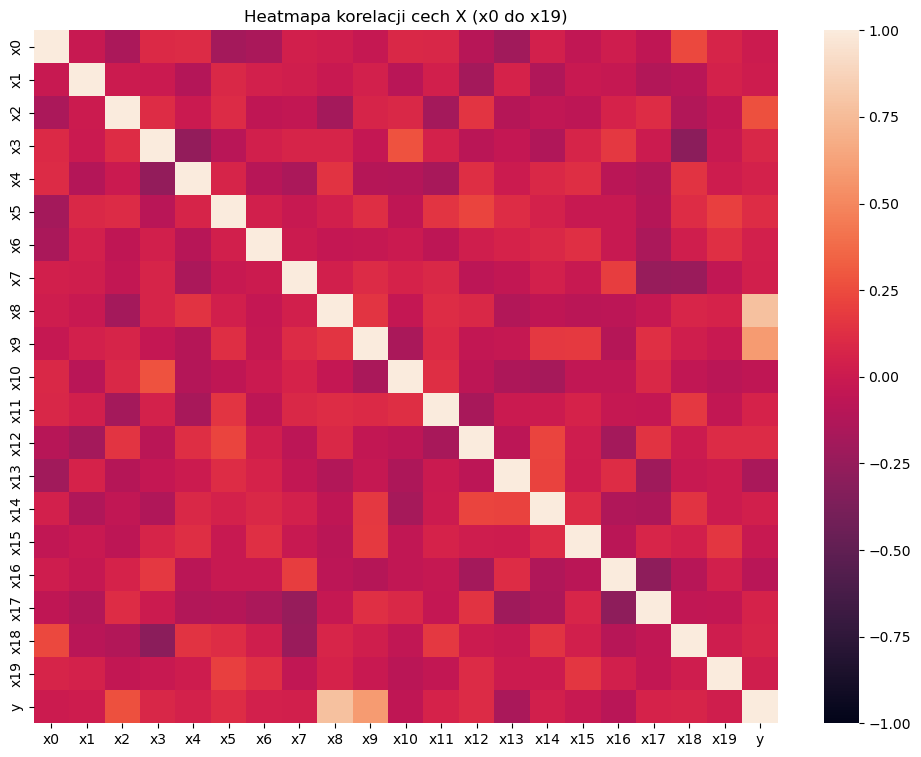

In [444]:
plt.figure(figsize=(12, 9))
corr_matrix = train_data.corr()
sns.heatmap(corr_matrix, vmin=-1, vmax=1)
plt.title('Heatmapa korelacji cech X (x0 do x19)')
plt.show()

In [445]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Klasyczna regresja liniowa

In [446]:
model_lr = LinearRegression(fit_intercept=True)
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

Funkcja strarty wraz z L2 korektą parametu $\theta \in \mathbb{R}^d$

$ \hat{y}(x) = \theta^{T} x = \sum_{i=0}^{d} \theta_i x^{(i)} $, gdzie $x^{(0)} \equiv 1$ (odpowiada za przesunięcie prostej)

$$
    Cost(\theta) = \frac{1}{N}\sum_{i=1}^{N}{(y_i - \hat{y}_{i})^{2}} + \lambda \sum_{j=0}^{d}{\theta_{j}^{2}}
$$

$$
    \frac{\partial Cost}{\partial \theta_j}(\theta) = -\frac{2}{N}\sum_{i=1}^{N}{(y_i - \hat{y}_{i}) \frac{\partial \hat{y}_{i}}{\partial \theta_j}}
    + 2\lambda\theta_j = -\frac{2}{N}\sum_{i=1}^{N}{(y_i - \hat{y}_{i}) x_i^{(j)}}
    + 2\lambda\theta_j
$$

Przyrównujemy do zera i zapisujmey wszystko jako rachunek na macierzach

$$
    \lambda N \theta = X^{T}(y - X\theta)
$$

$$
    (\lambda N I_{d} + X^{T}X)\theta = X^{T}y
$$

więc przy założeniu, że macierz jest odwracalna

$$
\theta(X, y, \lambda) = (\lambda N I_{d} + X^{T}X)^{-1}X^{T}y
$$

Teraz policzmy Hessian

$$
    \frac{\partial^{2} Cost}{\partial \theta_k \theta_j}(\theta) = \frac{2}{N}\sum_{i=1}^{N}{\frac{\partial \hat{y}_i}{\partial \theta_k} 
    x_{i}^{(j)}} = \frac{2}{N}\sum_{i=1}^{N}{x_{i}^{(k)} x_{i}^{(j)}}
$$

Czyli

$$
    Hess(Cost)(\theta) = \frac{2}{N} X^{T}X
$$

Ta macierz jest zawsze dodatnio-półokreślona, więc jeśli tylko jest odwracalna to jest dodatnio określona, więc w punkcie staconarnym mamy minimum. Na potrzeby praktyki możemy założyć, że tak jest.

In [447]:
def find_theta(X, y, lmbd=0.0):
    n_samples, n_features = X.shape
    X_ = np.c_[np.ones((n_samples, 1)), X] # dodajemy wyraz wolny 
    d = n_features + 1
    identity = np.eye(d)
    # M = lmbd * n_samples * identity + X_.T @ X_
    M = lmbd * identity + X_.T @ X_
    return np.linalg.inv(M) @ X_.T @ y

In [448]:
def predict(X, theta):
    n_samples = X.shape[0]
    X_ = np.c_[np.ones((n_samples, 1)), X] # dodajemy wyraz wolny 
    return X_.dot(theta)

In [453]:
# lambdas = np.logspace(-2, 3, 100)  # np od 1e-2 do 1e3, 100 wartości

lambdas = np.linspace(0, 10, 100)  # np od 0 do 10, 100 wartości

best_lambda = None
best_mse = np.inf
best_theta = None

for LAMBDA in lambdas:
    theta = find_theta(X_train_scaled, y_train, lmbd=LAMBDA)
    y_pred = predict(X_test_scaled, theta)
    mse = mean_squared_error(y_test, y_pred)
    
    if mse < best_mse:
        best_mse = mse
        best_lambda = LAMBDA
        best_theta = theta

print(f"Najlepsza lambda: {best_lambda:.5f}")
print(f"Najmniejszy MSE (custom model): {best_mse:.5f}")

mse_sklearn = mean_squared_error(model_lr.predict(X_test_scaled), y_test)
print(f"MSE (sklearn model): {mse_sklearn:.5f}")

Najlepsza lambda: 3.83838
Najmniejszy MSE (custom model): 71.88574
MSE (sklearn model): 114.48370


Pobór lamdaby w dużej mierze zależy tutaj od danych (co trafia do train a co do test) ..., trochę nie powinno tak być, cieżko mi było tutaj usystematyzować to